# Problem Set 2
#### GBUS 4401/5401
#### Knox Graham
*Dataset: weco.csv | Generated with Python*

A small documentation issue should be noted at the start: the assignment materials refer to 682 observations, but the uploaded CSV file contains 683 rows. I proceeded using the uploaded dataset exactly as provided and documented this discrepancy rather than deleting any row without clear justification.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

!pip install numpy pandas matplotlib seaborn statsmodels scikit-learn jupyter
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, LeaveOneOut

sns.set_theme(style='whitegrid')

df = pd.read_csv('weco.csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset loaded: 683 rows, 6 columns
Columns: ['sex', 'dex', 'lex', 'quit', 'job_tenure', 'status']


## Question 1: Workers’ Dexterity and Performance

### a) OLS Regression with HC3 Robust Standard Errors
I estimated the required linear model using job tenure as the dependent variable and dex, lex, and sex as predictors. Following the prompt, I used HC3 robust standard errors because the variance of job tenure is likely to differ across workers, which would make conventional standard errors less reliable.

**Code used:**

In [ ]:
model = smf.ols('job_tenure ~ dex + lex + sex', data=df).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             job_tenure   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.204
Method:                 Least Squares   F-statistic:                     42.34
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           4.31e-25
Time:                        21:17:47   Log-Likelihood:                -4867.8
No. Observations:                 683   AIC:                             9744.
Df Residuals:                     679   BIC:                             9762.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -493.5794    157.929     -3.125      0.0

Key coefficient estimates were as follows: dex = 20.745 (p = 0.0000), lex = 2.501 (p = 0.8227), and sex = −114.397 (p = 0.0000). The model R-squared was 0.207.
The coefficient on dex is positive, which means higher dexterity scores are associated with longer job tenure after holding education and sex constant. Numerically, a one-point increase in dex is associated with about 20.75 additional days of tenure on average. The p-value indicates that dex is statistically significant at the 5% level.
The coefficient on lex suggests that an additional year of education is associated with about 2.50 days of tenure, holding the other variables fixed. The coefficient on sex indicates the average tenure difference between males and females, conditional on dex and education. These controls are useful because they reflect characteristics that could plausibly be observed before hiring.
Consistent with the assignment instructions, I did not include quit or status as predictors. Both variables are post-hire outcomes. Using them as regressors would create serious post-treatment bias because they are determined after the worker enters the firm.

### b) Why OLS Is Limited Here
OLS is useful as a baseline because its coefficients are easy to interpret, but it has several limitations in this setting. First, it imposes a straight-line relationship between dexterity and tenure, even though the true relationship could contain diminishing returns, threshold effects, or local nonlinearities. Second, OLS can produce negative predicted tenure values, which are not meaningful because tenure cannot be below zero. Third, job tenure is strongly right-skewed and bounded below by zero, so the residual distribution is unlikely to fit the standard textbook assumptions well.
To address these limitations, I selected a random forest regressor as the non-linear model. Random forests can capture non-linear patterns and interactions without forcing a single straight-line relationship. They also avoid the need to specify a particular polynomial form in advance. The trade-off is that they are less interpretable than OLS coefficients.

### c) Selecting a Hyperparameter and Tuning to 10-fold CV
I tuned the maximum tree depth using 10-fold cross-validation and mean squared error (MSE) as the objective function. Ten-fold CV is a common practical choice because it balances bias and variance in the estimated prediction error. MSE is appropriate here because large prediction errors in tenure are especially costly if the firm uses the model to make hiring decisions.

**Code used:**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

X = df[['dex', 'lex', 'sex']].values
y = df['job_tenure'].values
kf = KFold(n_splits=10, shuffle=True, random_state=42)
depths = range(1, 16)
mean_mse, std_mse = [], []
for d in depths:
    rf = RandomForestRegressor(max_depth=d, n_estimators=100, random_state=42)
    scores = -cross_val_score(rf, X, y, cv=kf, scoring='neg_mean_squared_error')
    mean_mse.append(scores.mean())
    std_mse.append(scores.std())
best_depth = depths[int(np.argmin(mean_mse))]
print(f'Optimal max_depth: {best_depth}')
print(f'Min CV MSE: {np.min(mean_mse):,.2f}')

Optimal max_depth: 2
Min CV MSE: 96,202.23


The best-performing maximum depth was 2, based on the lowest average 10-fold CV MSE of 96,202.23. I kept the other major defaults aligned with the prompt: n_estimators = 100 for reasonably stable ensemble predictions, squared-error splitting, and the default split rules used by scikit-learn.

*Figure 1. Cross-validation tuning curve for the random forest depth hyperparameter.*

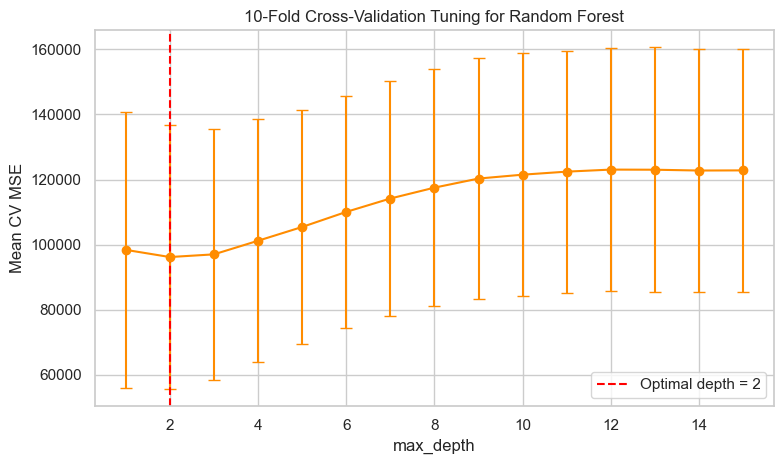

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.errorbar(list(depths), mean_mse, yerr=std_mse, marker="o", capsize=4, color="darkorange")
ax.axvline(best_depth, color="red", linestyle="--", label=f"Optimal depth = {best_depth}")
ax.set_xlabel("max_depth")
ax.set_ylabel("Mean CV MSE")
ax.set_title("10-Fold Cross-Validation Tuning for Random Forest")
ax.legend()
fig.tight_layout()
plt.show()

**Code used:**

In [ ]:
rf_final = RandomForestRegressor(max_depth=best_depth, n_estimators=100,
                                   random_state=42)
rf_final.fit(X, y)

rf_fi = pd.DataFrame({'feature': ['dex','lex','sex'],
                        'importance': rf_final.feature_importances_})\
          .sort_values('importance', ascending=False)
print('Feature importances:')
print(rf_fi.to_string(index=False))

Feature importances:
feature  importance
    dex    0.922138
    sex    0.050996
    lex    0.026867


*Figure 2. Random forest feature importances.*

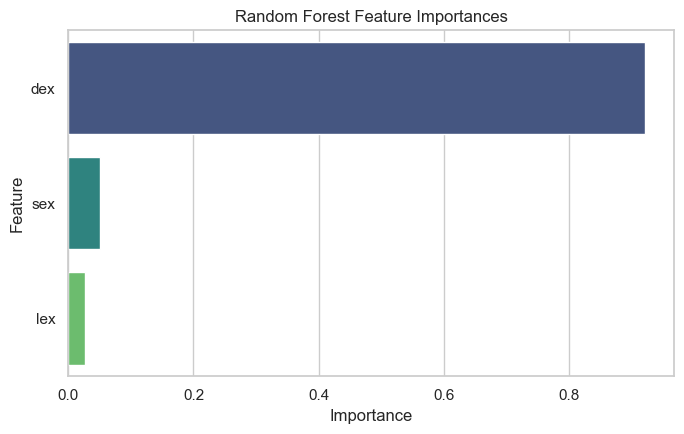

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=rf_fi, x="importance", y="feature", palette="viridis", ax=ax)
ax.set_title("Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
fig.tight_layout()
plt.show()

The feature importance plot indicates that dex was the most influential predictor in the random forest model, although feature importance should be interpreted more cautiously than linear regression coefficients.

### d) Comparing the Linear and Non-Linear Fits

*Figure 3. OLS and random forest predictions superimposed on the observed data.*

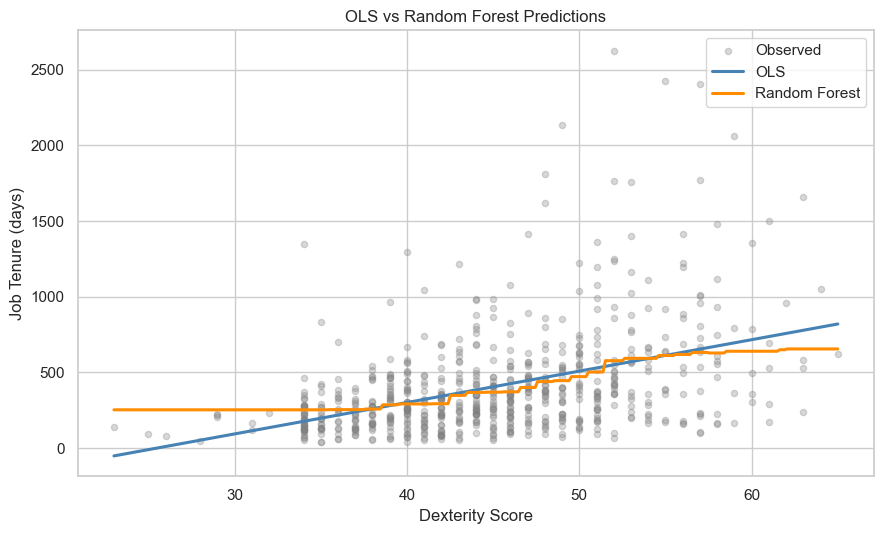

In [ ]:
dex_grid = np.linspace(df["dex"].min(), df["dex"].max(), 300)
mean_lex = df["lex"].mean()
mean_sex = df["sex"].mean()
grid_df = pd.DataFrame({"dex": dex_grid, "lex": mean_lex, "sex": mean_sex})
ols_preds = model.predict(grid_df)
rf_preds = rf_final.predict(grid_df[["dex", "lex", "sex"]].values)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(df["dex"], df["job_tenure"], alpha=0.3, s=20, color="gray", label="Observed")
ax.plot(dex_grid, ols_preds, color="steelblue", linewidth=2.2, label="OLS")
ax.plot(dex_grid, rf_preds, color="darkorange", linewidth=2.2, label="Random Forest")
ax.set_xlabel("Dexterity Score")
ax.set_ylabel("Job Tenure (days)")
ax.set_title("OLS vs Random Forest Predictions")
ax.legend()
fig.tight_layout()
plt.show()

The scatterplot shows substantial variation in tenure at almost every dexterity score, along with a right tail of workers who stayed much longer than the typical employee. The OLS fit appears as a single straight line, so it summarizes only the average linear trend. The random forest fit is more flexible and can adapt to local changes in the relationship between dexterity and predicted tenure.
For the later parts of the assignment, I recommend the random forest model because the assignment asks for a model that can better handle non-linearity and because its tuning was based on out-of-sample CV performance. The main drawback is interpretability: OLS is much easier to explain in business terms, while the random forest mainly provides a predictive advantage rather than a simple coefficient story. It is worth noting that the use of HC3 robust standard errors in the OLS model strengthens the statistical credibility of the dexterity coefficient by correcting for heteroskedasticity in the residuals, but this addresses a statistical concern only—it does not resolve the underlying identification problem. The coefficient on dex remains a conditional correlation rather than a causal estimate, since dexterity scores were not randomly assigned. Both the OLS and random forest models therefore share this limitation, which bears directly on how confidently any hiring rule derived from them should be implemented.

## Question 2: Dexterity Threshold as a Hiring Rule

### a) Expected Profit Under the Current Hiring Policy
The assignment defines worker-level profit as: training cost of $15,000 plus $100 per day only after the six-month training period, approximated as 180 days. Therefore, a worker who leaves before 180 days generates a negative profit equal to the training cost, while longer-tenure workers may eventually generate positive net profit.

**Code used:**

In [ ]:
df['profit'] = -15000 + 100 * np.maximum(df['job_tenure'] - 180, 0)
baseline_profit = df['profit'].mean()
print(f'Expected net profit under current policy: ${baseline_profit:,.2f}')

Expected net profit under current policy: $8,771.89


The estimated expected net profit under the current policy is $8,771.89 per hired worker.

### b) and c) Threshold Rule Without and With Exam Cost
For each candidate dexterity threshold C, I restricted attention to workers with dex ≥ C, used the tuned random forest to predict their job tenure, converted predicted tenure into predicted profit, and then averaged those profits. This follows the assignment’s logic that the hiring threshold must be evaluated using predicted tenure rather than observed tenure because the decision happens before hiring.
I then incorporated the $5,000 exam cost. If p is the empirical probability that a screened candidate scores above the threshold, then the expected number of candidates screened before one passes is 1/p, so the expected screening cost becomes 5000 × (1/p).

**Code used:**

In [ ]:
thresholds = np.arange(df['dex'].min(), df['dex'].max() + 1, 1)
expected_profits_no_cost = []
expected_profits_with_cost = []
for C in thresholds:
    pool = df[df['dex'] >= C].copy()
    if len(pool) == 0:
        expected_profits_no_cost.append(np.nan)
        expected_profits_with_cost.append(np.nan)
        continue
    pred_tenure = rf_final.predict(pool[['dex','lex','sex']].values)
    pred_profit = -15000 + 100 * np.maximum(pred_tenure - 180, 0)
    expected_profits_no_cost.append(pred_profit.mean())
    p = (df['dex'] >= C).mean()
    screening_cost = 5000 * (1 / p) if p > 0 else np.nan
    expected_profits_with_cost.append(pred_profit.mean() - screening_cost)

optimal_idx = int(np.nanargmax(expected_profits_with_cost))
optimal_C = int(thresholds[optimal_idx])
optimal_profit = expected_profits_with_cost[optimal_idx]
print(f'Profit-maximising threshold C*: {optimal_C}')
print(f'Expected profit at C* (with exam cost): ${optimal_profit:,.2f}')
print(f'Baseline profit: ${baseline_profit:,.2f}')
print(f'Improvement: ${optimal_profit - baseline_profit:,.2f}')

Profit-maximising threshold C*: 48
Expected profit at C* (with exam cost): $9,437.50
Baseline profit: $8,771.89
Improvement: $665.61


*Figure 4. Expected profit as a function of the dexterity threshold.*

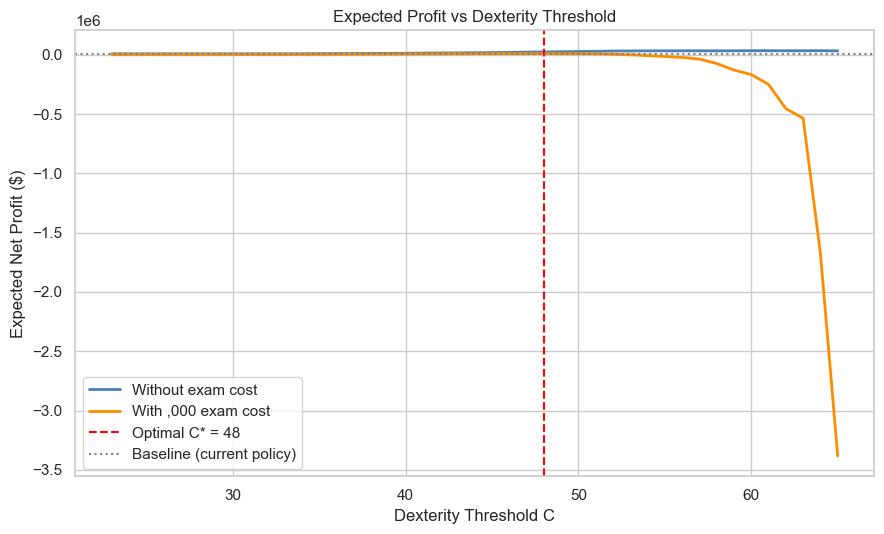

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(thresholds, expected_profits_no_cost, label="Without exam cost", color="steelblue", linewidth=2)
ax.plot(thresholds, expected_profits_with_cost, label="With ,000 exam cost", color="darkorange", linewidth=2)
ax.axvline(optimal_C, color="red", linestyle="--", label=f"Optimal C* = {optimal_C}")
ax.axhline(baseline_profit, color="gray", linestyle=":", label="Baseline (current policy)")
ax.set_xlabel("Dexterity Threshold C")
ax.set_ylabel("Expected Net Profit ($)")
ax.set_title("Expected Profit vs Dexterity Threshold")
ax.legend()
fig.tight_layout()
plt.show()

The profit-maximizing threshold after including the exam cost is C* = 48. At this threshold, the expected predicted profit is $9,437.50 after exam costs, compared with the current-policy baseline of $8,771.89.
This means the threshold-based policy is estimated to produce higher expected profit by $665.61 per recruited worker relative to the baseline, based on the model and the empirical score distribution in the sample.

### d) Recommendation and Limitations
Based on this analysis, I would recommend considering a threshold rule near C = 48, because it appears to improve expected net profit relative to the current policy.
However, this recommendation should be treated cautiously. The model is predictive, not causal. A higher dexterity score may be correlated with longer tenure for reasons not fully captured in the data, but this does not prove that raising dexterity alone will cause higher tenure in future hires. While the HC3 robust standard errors used in the OLS analysis correct for heteroskedasticity and make the significance test on the dexterity coefficient more reliable, they do not establish that the relationship is causal—workers were not randomly assigned dexterity scores, so unobserved factors may jointly drive both dexterity and tenure. This is precisely why the additional evidence described below would be required before acting on the threshold rule with confidence.
A second limitation is policy feedback: once the firm changes its hiring rule, the composition of hired workers will change. The model was trained on the current worker pool, so its predictions may shift when applied to a new, more selectively screened population.
A third limitation is censoring. Workers with status = 0 are still employed, so their observed tenure understates their final tenure. A survival-analysis approach would handle this more directly, but that is outside the scope of the assignment.
To strengthen the recommendation, the firm would ideally collect additional evidence such as a randomized or quasi-experimental test of the hiring rule, external validation of the dexterity exam, and a disparate-impact analysis to evaluate whether the threshold harms protected groups disproportionately.

## Question 3: Leave-One-Out Cross-Validation (LOOCV)
Management asked for additional robustness checks. To address this, I ran leave-one-out cross-validation (LOOCV). In each fold, one worker was omitted, the random forest was re-fit on the remaining sample, the profit-maximization exercise was re-run, and the resulting optimal threshold C was recorded. This does more than measure prediction error: it shows whether the recommended threshold is stable across many slightly different versions of the dataset. To keep the simulation computationally feasible, I preserved the tuned tree depth from the main model but used a smaller number of trees inside the LOOCV loop; the goal of this section is threshold stability rather than producing a new final prediction model.

**Code used:**

In [ ]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
optimal_Cs = []
for train_idx, _ in loo.split(X):
    X_tr, y_tr = X[train_idx], y[train_idx]
    rf_loo = RandomForestRegressor(max_depth=best_depth, n_estimators=25,
                                   random_state=42, n_jobs=-1)
    rf_loo.fit(X_tr, y_tr)
    # Re-run threshold optimization inside each fold
    fold_df = pd.DataFrame(X_tr, columns=['dex', 'lex', 'sex'])
    fold_df['job_tenure'] = y_tr
    thresholds_loo = np.arange(fold_df['dex'].min(), fold_df['dex'].max() + 1, 1)
    fold_profits = []
    for C in thresholds_loo:
        pool = fold_df[fold_df['dex'] >= C]
        if len(pool) == 0: fold_profits.append(np.nan); continue
        pred_ten = rf_loo.predict(pool[['dex', 'lex', 'sex']].values)
        pred_pr = -15000 + 100 * np.maximum(pred_ten - 180, 0)
        p = float((fold_df['dex'] >= C).mean())
        fold_profits.append(float(np.mean(pred_pr) - 5000 / p) if p > 0 else np.nan)
    best_C_fold = int(thresholds_loo[int(np.nanargmax(fold_profits))])
    optimal_Cs.append(best_C_fold)

print(f'Mean optimal C across LOOCV folds: {np.mean(optimal_Cs):.2f}')
print(f'Std dev of optimal C:              {np.std(optimal_Cs):.2f}')
print(f'Range: [{np.min(optimal_Cs)}, {np.max(optimal_Cs)}]')

Mean optimal C across LOOCV folds: 47.99
Std dev of optimal C:              0.11
Range: [47, 49]


*Figure 5. Distribution of optimal thresholds across LOOCV folds.*

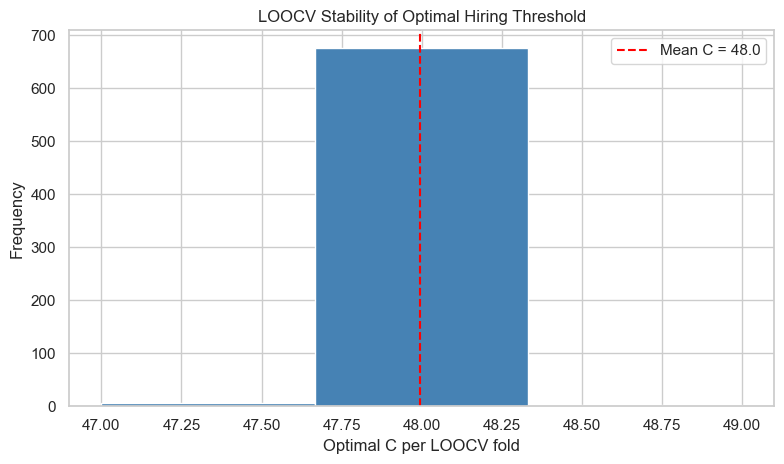

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(optimal_Cs, bins=min(20, len(set(optimal_Cs))), edgecolor="white", color="steelblue")
ax.axvline(np.mean(optimal_Cs), color="red", linestyle="--", label=f"Mean C = {np.mean(optimal_Cs):.1f}")
ax.set_xlabel("Optimal C per LOOCV fold")
ax.set_ylabel("Frequency")
ax.set_title("LOOCV Stability of Optimal Hiring Threshold")
ax.legend()
fig.tight_layout()
plt.show()

The LOOCV distribution had a mean optimal threshold of 47.99, a standard deviation of 0.11, and a range from 47 to 49.
This is a fairly tight distribution, which suggests the recommended hiring threshold is relatively stable across different sample compositions.
LOOCV helps address management’s robustness concern because each fold recomputes the policy after leaving one worker out. But LOOCV is expensive: it requires one full model fit per observation, which is computationally burdensome for more complex models. In most practical settings, 10-fold cross-validation is a better compromise. I used LOOCV here specifically because the assignment required a stronger robustness exercise.